In [1]:
### Run the line below if PSG_POWER_PYTHON is not installed
!pip install --upgrade somnopy
# !pip install mne


In [1]:
# ----------------- Load packages ------------------- #
import os
import shutil
import contextlib
import io
import numpy as np
import pandas as pd
import mne
from scipy.io import loadmat
import warnings
import matplotlib.pyplot as plt
import time
from pathlib import Path

from datetime import datetime
today_str = datetime.now().strftime("%Y-%m-%d")


from somnopy import *
from somnopy.somno import get_sosp, get_sosp_for_folder
from somnopy.event_detection import SO_detection, SP_detection, detect_swa
from somnopy.metrics import pac, event_lock
#from somnopy.polysomnography import HumeDataLoader, RemLogicDataLoader
from somnopy.utils import set_up_raw
from somnopy.polysomnography import PolySomnoGraphy


In [ ]:
###The following are REQUIRED PARAMETERS:

# data_path should point to a folder of folders. Each folder within data_path will have its .edf and .txt / .mat contents analyzed separately
# output_path should point to a folder where you want to store your results. 

# Subfolders within output_path will match the names of the subfolders within data_path
# If matching subfolders have not been created yet, they will be created automatically 
# Each subfolder will store results for the corresponding .edf files in data_path

# Group data into subfolders however you would like. If you want metrics per participant, make sure each .edf and .txt / .mat
# file is stored in it's own subfolder in data_path per participant. If you want metrics across all participants, just
# create one subfolder within data_path for all .edf and .txt files

# Make sure each .edf filename matches its corresponding .txt / .mat file

data_path = Path("Y:\\SNL\\Ryan\\somnopy\\somnopy\\data")
output_path = Path("C:\\Users\\Beast\\Ryan\\somnopy\\somnopy\\output")

###The following are OPTIONAL PARAMETERS, the default value is what you see, update as necessary:
interest_stage = ['N2', 'SWS'] #sleep stages interested in evaluating
sp_method = 'Hahn2020' #Method used for spindle detection. See available methods below
so_method = 'Staresina' #Method used for slow oscillation detection. See available methods below
coupling = True #If set to true, additional metrics such as PAC, or spindle to slow oscillation coupling percentage will be calulated and plotted
scoring_dur = 30 # (in seconds) the duration of each epoch used for sleep scoring
rereference = False # If reference channels are not contralateral mostoids or you are unsure, otherwise set to: rereference = ['M1', 'M2'], also optional to set 'average' to use the average of all channels as reference
chan_limit = ['F3', 'C3', 'F4', 'C4'] # Use None to process all channels, or use ['Fz', 'Cz', 'F3', 'C3', ...] to process selected channels only.
channels_to_drop = ['E1', 'E2', 'ChinC', 'ChinL', 'ChinR'] #by default, will drop non-eeg channels. Add any channels that you would want to drop completely
montage_temp = "standard_1005" # Use standard_1005 for mid and high-density caps, standard_1020 for low-density caps, or specify another montage. See other available montages below
baseline = True # Baseline correction before the event detection
verbose = True # Additional diagnostic plotting/ printing if set to true
#The following are customisable Slow Oscillatoin detection metrics, that have different default depending on method used
#filter_freq = None
#duration = None
#filter_type = 'fir'
#The following are customisable Spindle detection metrics, that have different default depending on method used
#l_freq = None
#h_freq = None
#dur_lower = None
#dur_upper = None


In [ ]:
#get the folder paths to pass into the get_sosp_for_folder function
input_paths = [str(p) for p in data_path.iterdir() if p.is_dir()]

#create output folders if they don't exist
for folder in input_paths:
    folder_name = Path(folder).name
    new_folder = output_path / folder_name
    new_folder.mkdir(parents=True, exist_ok=True)

#store output paths
output_paths = [str(p) for p in output_path.iterdir() if p.is_dir()]
    

In [21]:
print(output_paths)
print(input_paths)

['C:\\Users\\Beast\\Ryan\\somnopy\\somnopy\\output\\dummy', 'C:\\Users\\Beast\\Ryan\\somnopy\\somnopy\\output\\emo_cuing', 'C:\\Users\\Beast\\Ryan\\somnopy\\somnopy\\output\\participant1', 'C:\\Users\\Beast\\Ryan\\somnopy\\somnopy\\output\\participant2']
['Y:\\SNL\\Ryan\\somnopy\\somnopy\\data\\emo_cuing', 'Y:\\SNL\\Ryan\\somnopy\\somnopy\\data\\participant1', 'Y:\\SNL\\Ryan\\somnopy\\somnopy\\data\\participant2']


RUNNING C:\Users\Beast\Ryan\somnopy\somnopy\data\participant2
Start event detection for subject MD_01.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Detected SOs in stage N2
Method: Staresina
PTP amplitude: 104.6080
Mean Duration: 1.2836
SO Density per 30s: 3.0000
Total Count: 432
---------------------------------------------------------------
Detected SOs in stage SWS
Method: Staresina
PTP amplitude: 266.1300
Mean Duration: 1.2046
SO Density per 30s: 2.9535
Total Count: 1524
---------------------------------------------------------------
Detected SPs in stage N2
Method: Hahn2020
Average Amplitude: 9.5058 uv
Average Duration: 0.8104s
Spindle Density (per 30s): 2.9653
Total Spindle Count: 427
---------------------------------------------------------------
Detected SPs in stage SWS
Method: Hahn2020
Average Amplitude: 8.1224 uv
Average Duration: 0.7925s
Spindle Density (per 30s): 3.2267
Total Spindle Count: 1665
-------------------------------------------

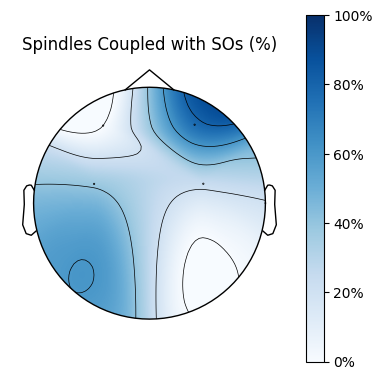

Stage N2:
Preferred Phase:       2.822 rad
Modulation Index:      0.030
Mean Vector Length:    0.051
Rayleigh z:            0.439
p-value:               0.928
Coupling Density:      1.870
Stage SWS:
Preferred Phase:       -3.127 rad
Modulation Index:      0.013
Mean Vector Length:    0.158
Rayleigh z:            12.638
p-value:               0.000
Coupling Density:      1.638


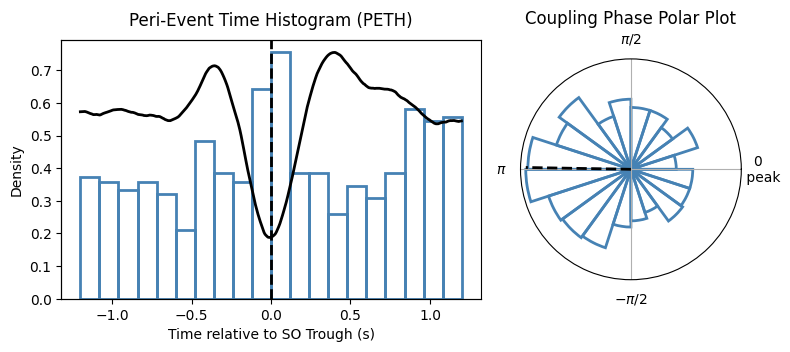

📄 Saved: \somnopy_summary_2026-03-02.csv
✅ Finished C:\Users\Beast\Ryan\somnopy\somnopy\data\participant2 in 0m 49s


In [ ]:
#run analyses
#figs should auto save out



#run through all participant folders
for input_folder, output_folder in zip(input_paths, output_paths):
    input_path = Path(input_folder)
    output_path = Path(output_folder)

    print(f"RUNNING {input_folder}")
    
    #try running SOSP
    try:
        start_time = time.time()
        #run analysis function
        event_summary_all, coupling_event_all, so_waveform_all = get_sosp_for_folder(
            input_folder,
            input_folder,
            chan_limit=chan_limit,
            coupling=coupling,
            interest_stage=interest_stage,
            sp_method=sp_method,
            so_method=so_method,
            scoring_dur=scoring_dur
        )
        
        #save summary for each eeg file within single participant as csv. From what I understand, there should only be one of these typically
        for filename, summary in event_summary_all.items():
            csv_name = f"\\somnopy_summary_{today_str}.csv"
            summary.to_csv(output_folder + csv_name)
            print(f"📄 Saved: {csv_name}")
            
        end_time = time.time()
        duration = end_time - start_time
        print(f"✅ Finished {folder} in {int(duration//60)}m {int(duration%60)}s")


    except Exception as e:
        print(f"❌ Error processing {folder}: {e}")

    break


In [ ]:
#run analyses
#figs should auto save out



#run through all participant folders
for folder in folder_paths:
    folder_path = Path(folder)
    print(f"RUNNING {folder}")
    """
    #try running SOSP
    try:
        start_time = time.time()
        #run analysis function
        event_summary_all, coupling_event_all, so_waveform_all = get_sosp_for_folder(
            folder,
            folder,
            chan_limit=chan_limit,
            coupling=coupling,
            interest_stage=interest_stage,
            sp_method=sp_method,
            so_method=so_method,
            scoring_dur=scoring_dur
        )
        
        #save summary for each eeg file within single participant as csv. From what I understand, there should only be one of these typically
        for filename, summary in event_summary_all.items():
            csv_name = f"\\somnopy_summary_{today_str}.csv"
            output_path = folder + csv_name
            summary.to_csv(output_path)
            print(f"📄 Saved: {csv_name}")
            
        end_time = time.time()
        duration = end_time - start_time
        print(f"✅ Finished {folder} in {int(duration//60)}m {int(duration%60)}s")

    except Exception as e:
        print(f"❌ Error processing {folder}: {e}")
        
    """    
    #try running SWA detection
    try:
        #get eeg file and scoring file paths. Old code passed in folder paths, which from what I can see is incorrect. Variable names need to be edited within the package to reflect this
        #the function needs the paths to the actual files. Additionally, I am storing them in lists in case there is multiple
        #Can there be multiple scoring files and eeg files per folder? Seems like it in the code for the package
        print('STARTING SWA ANALYSIS')
        eeg_files = [str(f) for f in folder_path.glob("*.edf")]
        scoring_files = [str(f) for f in folder_path.glob("*.txt")]
        scoring_files += [str(f) for f in folder_path.glob("*.mat")]
        
        #iterate through eeg and scoring files
        for eeg_file, scoring_file in zip(eeg_files, scoring_files):
            print(f'ANALYZING {eeg_file}')
            print(f'ANALYZING {scoring_file}')
            psg = PolySomnoGraphy(eeg_path=eeg_file, hypnogram_path=scoring_file)
            psg.set_up_raw(
                channels_to_drop=channels_to_drop,
                chan_limit=chan_limit,
                rereference=rereference,
                montage_temp=montage_temp
            )
            swa = psg.detect_swa(stages = sleep_stages)
            print(f'{eeg_file} ANALYSIS COMPLETE')

        print('ALL FILES ANALYZED')
            
    except Exception as swa_error:
        print(f"❌ Error in SWA detection for {folder}: {swa_error}")

    break

"""            
            #results
            swa_results_all = {}
            
            #run SWA for each sleep stage
            for stage in sleep_stages:
                print(f"   Detecting SWA in stage {stage}...")
                
                #get channel names
                channels = psg.raw.ch_names if chan_limit is None else chan_limit
                eeg_channels = [ch for ch in channels if ch not in channels_to_drop]
                
                for channel in eeg_channels:
                    try:
                        # Run SWA detection for this channel and stage
                        swa_events = detect_swa(
                            psg.raw,
                            psg.hypnogram, 
                            stage=stage,
                            channel=channel,
                            baseline=baseline
                        )
                        
                        # Store results
                        key = f"{stage}_{channel}"
                        swa_results_all[key] = swa_events
                        
                        if swa_events is not None and len(swa_events) > 0:
                            print(f"     {channel}: Found {len(swa_events)} SWA events")
                        else:
                            print(f"     {channel}: No SWA events found")
                        
                    except Exception as e:
                        print(f"     ⚠️ {channel}: Error in SWA detection - {e}")
                        swa_results_all[f"{stage}_{channel}"] = None
        
        # ----------------- STEP 3C: Save SWA Results ------------------- #
        swa_csv_name = f"SWA_{folder_name}_{today_str}.csv"
        swa_csv_path = os.path.join(folder_path, swa_csv_name)
        
        # Convert SWA results to DataFrame format
        swa_summary_data = []
        for key, events in swa_results_all.items():
            stage_name, channel = key.rsplit('_', 1)
            
            if events is not None and len(events) > 0:
                # Calculate summary statistics
                if hasattr(events, 'duration'):
                    durations = events.duration if hasattr(events.duration, '__iter__') else [events.duration]
                    mean_duration = np.mean(durations)
                    total_count = len(durations)
                else:
                    # If events is a DataFrame or similar structure
                    mean_duration = np.nan
                    total_count = len(events) if hasattr(events, '__len__') else 1
                    
                swa_summary_data.append({
                    'stage': stage_name,
                    'channel': channel,
                    'swa_count': total_count,
                    'mean_duration': mean_duration,
                    'swa_density': total_count / (psg.get_stage_duration(stage_name) / 30) if hasattr(psg, 'get_stage_duration') else np.nan
                })
            else:
                swa_summary_data.append({
                    'stage': stage_name,
                    'channel': channel,
                    'swa_count': 0,
                    'mean_duration': np.nan,
                    'swa_density': 0
                })
        
        # Save SWA summary to CSV
        if swa_summary_data:
            swa_df = pd.DataFrame(swa_summary_data)
            swa_df.to_csv(swa_csv_path, index=False)
            print(f"🌊 Saved SWA results: {swa_csv_name}")
        else:
            print(f"⚠️ No SWA data to save for {folder_name}")
"""                 






RUNNING C:\Users\Beast\Ryan\somnopy\somnopy\data\dummy
STARTING SWA ANALYSIS
ANALYZING C:\Users\Beast\Ryan\somnopy\somnopy\data\dummy\MD_01.edf
ANALYZING C:\Users\Beast\Ryan\somnopy\somnopy\data\dummy\MD_01.txt
❌ Error in SWA detection for C:\Users\Beast\Ryan\somnopy\somnopy\data\dummy: 'NoneType' object has no attribute 'lower'


'            \n            #results\n            swa_results_all = {}\n\n            #run SWA for each sleep stage\n            for stage in sleep_stages:\n                print(f"   Detecting SWA in stage {stage}...")\n\n                #get channel names\n                channels = psg.raw.ch_names if chan_limit is None else chan_limit\n                eeg_channels = [ch for ch in channels if ch not in channels_to_drop]\n\n                for channel in eeg_channels:\n                    try:\n                        # Run SWA detection for this channel and stage\n                        swa_events = detect_swa(\n                            psg.raw,\n                            psg.hypnogram, \n                            stage=stage,\n                            channel=channel,\n                            baseline=baseline\n                        )\n\n                        # Store results\n                        key = f"{stage}_{channel}"\n                        swa_results_a

In [ ]:
# ----------------- STEP 2 & 3: Run Processing + Save CSV (WITH SWA DETECTION) ------------------- #
print("\n⚙️ STEP 2: Running analysis with SWA detection and saving output...\n")

for folder_name in os.listdir(root_dir):
    folder_path = os.path.join(root_dir, folder_name)

    if os.path.isdir(folder_path) and folder_name.startswith("HSR"):
        print(f"\n🧠 Processing: {folder_name}")
        processed_eeg_folder = folder_path
        scoring_file = folder_path

        try:
            start_time = time.time()

            # Standard SOSP analysis
            event_summary_all, coupling_event_all, so_waveform_all = get_sosp_for_folder(
                processed_eeg_folder,
                scoring_file,
                chan_limit=chan_limit,
                coupling=coupling,
                interest_stage=interest_stage,
                sp_method=sp_method,
                so_method=so_method,
                scoring_dur=scoring_dur
            )

            # ----------------- STEP 3A: Save Standard Output CSV ------------------- #
            if isinstance(event_summary_all, dict):
                for key, df in event_summary_all.items():
                    if isinstance(df, pd.DataFrame):
                        key_safe = key.replace(" ", "_").replace("/", "_")
                        csv_name = f"Somnopy_{folder_name}_{today_str}.csv"
                        csv_path = os.path.join(folder_path, csv_name)
                        df.to_csv(csv_path, index=False)
                        print(f"📄 Saved: {csv_name}")
            else:
                print(f"⚠️ Unexpected format for event_summary_all in {folder_name}")

            # ----------------- STEP 3B: SWA Detection ------------------- #
            print(f"🌊 Running SWA detection for {folder_name}...")
            
            try:
                # Load PSG data for SWA detection
                psg = PolySomnoGraphy(processed_eeg_folder, scoring_file)
                psg.set_up_raw(
                    channels_to_drop=channels_to_drop,
                    chan_limit=chan_limit,
                    rereference=rereference,
                    montage_temp=montage_temp
                )
                
                # Dictionary to store SWA results for all channels
                swa_results_all = {}
                
                # Run SWA detection for each stage of interest
                for stage in interest_stage:
                    print(f"   Detecting SWA in stage {stage}...")
                    
                    # Get channel names
                    channels = psg.raw.ch_names if chan_limit is None else chan_limit
                    eeg_channels = [ch for ch in channels if ch not in channels_to_drop]
                    
                    for channel in eeg_channels:
                        try:
                            # Run SWA detection for this channel and stage
                            swa_events = detect_swa(
                                psg.raw,
                                psg.hypnogram, 
                                stage=stage,
                                channel=channel,
                                baseline=baseline
                            )
                            
                            # Store results
                            key = f"{stage}_{channel}"
                            swa_results_all[key] = swa_events
                            
                            if swa_events is not None and len(swa_events) > 0:
                                print(f"     {channel}: Found {len(swa_events)} SWA events")
                            else:
                                print(f"     {channel}: No SWA events found")
                                
                        except Exception as e:
                            print(f"     ⚠️ {channel}: Error in SWA detection - {e}")
                            swa_results_all[f"{stage}_{channel}"] = None
                
                # ----------------- STEP 3C: Save SWA Results ------------------- #
                swa_csv_name = f"SWA_{folder_name}_{today_str}.csv"
                swa_csv_path = os.path.join(folder_path, swa_csv_name)
                
                # Convert SWA results to DataFrame format
                swa_summary_data = []
                for key, events in swa_results_all.items():
                    stage_name, channel = key.rsplit('_', 1)
                    
                    if events is not None and len(events) > 0:
                        # Calculate summary statistics
                        if hasattr(events, 'duration'):
                            durations = events.duration if hasattr(events.duration, '__iter__') else [events.duration]
                            mean_duration = np.mean(durations)
                            total_count = len(durations)
                        else:
                            # If events is a DataFrame or similar structure
                            mean_duration = np.nan
                            total_count = len(events) if hasattr(events, '__len__') else 1
                            
                        swa_summary_data.append({
                            'stage': stage_name,
                            'channel': channel,
                            'swa_count': total_count,
                            'mean_duration': mean_duration,
                            'swa_density': total_count / (psg.get_stage_duration(stage_name) / 30) if hasattr(psg, 'get_stage_duration') else np.nan
                        })
                    else:
                        swa_summary_data.append({
                            'stage': stage_name,
                            'channel': channel,
                            'swa_count': 0,
                            'mean_duration': np.nan,
                            'swa_density': 0
                        })
                
                # Save SWA summary to CSV
                if swa_summary_data:
                    swa_df = pd.DataFrame(swa_summary_data)
                    swa_df.to_csv(swa_csv_path, index=False)
                    print(f"🌊 Saved SWA results: {swa_csv_name}")
                else:
                    print(f"⚠️ No SWA data to save for {folder_name}")
                    
            except Exception as swa_error:
                print(f"❌ Error in SWA detection for {folder_name}: {swa_error}")
                
            end_time = time.time()
            duration = end_time - start_time
            print(f"✅ Finished {folder_name} in {int(duration//60)}m {int(duration%60)}s")

        except Exception as e:
            print(f"❌ Error processing {folder_name}: {e}")

# ----------------- ALTERNATIVE: Simple SWA Detection Integration ------------------- #
# Run this cell if the above cell encounters issues with detect_swa parameters

print("\n🌊 ALTERNATIVE: Simple SWA Detection for all processed folders...\n")

for folder_name in os.listdir(root_dir):
    folder_path = os.path.join(root_dir, folder_name)

    if os.path.isdir(folder_path) and folder_name.startswith("HSR"):
        print(f"\n🌊 Running SWA detection for: {folder_name}")
        
        try:
            # Load PSG data
            psg = PolySomnoGraphy(folder_path, folder_path)
            psg.set_up_raw(
                channels_to_drop=channels_to_drop,
                chan_limit=chan_limit,
                rereference=rereference,
                montage_temp=montage_temp
            )
            
            # Initialize SWA results storage
            swa_results = []
            
            # Get EEG channels
            eeg_channels = chan_limit if chan_limit is not None else psg.raw.ch_names
            eeg_channels = [ch for ch in eeg_channels if ch not in channels_to_drop]
            
            for stage in interest_stage:
                print(f"   Stage {stage}:")
                for channel in eeg_channels:
                    try:
                        # Try basic detect_swa call - adjust parameters as needed
                        swa_events = detect_swa(psg.raw, psg.hypnogram, stage, channel)
                        
                        if swa_events is not None:
                            # Extract relevant metrics
                            if hasattr(swa_events, '__len__'):
                                swa_count = len(swa_events)
                            else:
                                swa_count = 1 if swa_events else 0
                                
                            swa_results.append({
                                'folder': folder_name,
                                'stage': stage,
                                'channel': channel,
                                'swa_count': swa_count,
                                'swa_events': str(swa_events)  # Store as string for CSV
                            })
                            
                            print(f"     {channel}: {swa_count} SWA events")
                        else:
                            swa_results.append({
                                'folder': folder_name,
                                'stage': stage,
                                'channel': channel,
                                'swa_count': 0,
                                'swa_events': 'None'
                            })
                            print(f"     {channel}: No SWA events")
                            
                    except Exception as e:
                        print(f"     ⚠️ {channel}: Error - {str(e)[:50]}...")
                        swa_results.append({
                            'folder': folder_name,
                            'stage': stage,
                            'channel': channel,
                            'swa_count': 0,
                            'swa_events': f'Error: {str(e)[:50]}'
                        })
            
            # Save results for this folder
            if swa_results:
                folder_swa_df = pd.DataFrame([r for r in swa_results if r['folder'] == folder_name])
                swa_csv_path = os.path.join(folder_path, f"SWA_Simple_{folder_name}_{today_str}.csv")
                folder_swa_df.to_csv(swa_csv_path, index=False)
                print(f"🌊 Saved: SWA_Simple_{folder_name}_{today_str}.csv")
                
        except Exception as e:
            print(f"❌ Error processing {folder_name}: {e}")


In [ ]:

# --- STEP 1: Duplicate -Events.txt to [folder_name].txt --- #
print("📁 STEP 1: Creating [folder_name].txt from -Events.txt...\n")

for folder_name in os.listdir(root_dir):
    folder_path = os.path.join(root_dir, folder_name)
    if os.path.isdir(folder_path) and folder_name.startswith("HSR"):
        # Find first -Events.txt file in the folder
        event_file = next(
            (f for f in os.listdir(folder_path) if f.endswith(".txt")),
            None
        )
        if event_file:
            old_path = os.path.join(folder_path, event_file)
            new_filename = f"{folder_name}.txt"
            new_path = os.path.join(folder_path, new_filename)

            if not os.path.exists(new_path):
                shutil.copy2(old_path, new_path)
                print(f"✓ {folder_name}: Created {new_filename}")
            else:
                print(f"• {folder_name}: Skipped (already exists: {new_filename})")
        else:
            print(f"⚠️ {folder_name}: No '-Events.txt' file found")


📁 STEP 1: Creating [folder_name].txt from -Events.txt...

• HSR127_W2_V1_Overnight: Skipped (already exists: HSR127_W2_V1_Overnight.txt)
• HSR128_W1_V1_Overnight: Skipped (already exists: HSR128_W1_V1_Overnight.txt)
• HSR128_W1_V2_Overnight: Skipped (already exists: HSR128_W1_V2_Overnight.txt)
• HSR129_W1_V1_Overnight: Skipped (already exists: HSR129_W1_V1_Overnight.txt)
• HSR129_W1_V2_Overnight: Skipped (already exists: HSR129_W1_V2_Overnight.txt)
• HSR129_W2_V1_Overnight: Skipped (already exists: HSR129_W2_V1_Overnight.txt)
• HSR130_W1_V1_Overnight: Skipped (already exists: HSR130_W1_V1_Overnight.txt)
• HSR130_W1_V2_Overnight: Skipped (already exists: HSR130_W1_V2_Overnight.txt)
• HSR132_W1_V1_Overnight: Skipped (already exists: HSR132_W1_V1_Overnight.txt)
• HSR132_W1_V2_Overnight: Skipped (already exists: HSR132_W1_V2_Overnight.txt)
✓ HSR132_W2_V1_OVERNIGHT: Created HSR132_W2_V1_OVERNIGHT.txt
✓ HSR132_W2_V2_OVERNIGHT: Created HSR132_W2_V2_OVERNIGHT.txt
• HSR133_W1_V1_Overnight: Skip

In [27]:
### Available Spindle detection methods:

'''
1) hahn2020 (default)
       - 12-16 Hz bandpass filter, Hilbert transform to obtain amplitude envelope,
         thresholded at a given percentile (default 75th),
         with a duration criterion of 0.5 to 3 seconds.

    2) martin2013
       - 11-15 Hz bandpass filter (linear phase FIR, forward and reverse for 0-phase distortion).
       - Compute RMS of the filtered signal with a 0.25 s time window.
       - Threshold at its 95th percentile (published criteria: Schabus et al., 2007).
       - A spindle is identified if at least two consecutive RMS time points
         exceed the threshold, and total duration >= 0.5 s.

    3) wamsley2012
       - Discrete sleep spindle events detected using a wavelet-based algorithm
         with an 8-parameter complex Morlet wavelet, ~10-16 Hz range.
       - Spindles are identified at each channel by a thresholding algorithm
         applied to the wavelet scale corresponding to 10-16 Hz.
       - The rectified moving average of this wavelet signal is calculated
         with a 100 ms sliding window.
       - Threshold = 4.5 times the mean signal amplitude across artifact-free epochs.
       - Duration >= 0.4 s to count as a spindle.

    4) Wendt2012
       - The raw data are bandpass filtered between 11-16 Hz.
       - The signal is then rectified.
       - Two separate lowpass filters are applied to create two envelopes
         (one ~2.25 Hz passband with offset 3 μV, the other ~1 Hz passband with offset 8 μV).
       - A time-varying threshold is formed by each envelope + offset.
       - Any rectified signal crossing either threshold boundary within 0.5-3 s
         is considered a spindle candidate. A final decision fusion is applied

    5) Ferrarelli2007
       - 12-15 Hz bandpass filter (–3 dB at 12 and 15 Hz).
       - The amplitude of the rectified filtered signal is used as the time series.
       - If the signal's amplitude exceeds an upper threshold (8 × channel average amplitude),
         it is considered a spindle candidate. Peak amplitude is the local maximum above
         that threshold. The start and end are the preceding/following points
         where amplitude drops below a lower threshold (2 × channel average amplitude).
       - Duration >= 0.5 s is typically required (AASM-based).
'''

"\n1) hahn2020 (default)\n       - 12-16 Hz bandpass filter, Hilbert transform to obtain amplitude envelope,\n         thresholded at a given percentile (default 75th),\n         with a duration criterion of 0.5 to 3 seconds.\n\n    2) martin2013\n       - 11-15 Hz bandpass filter (linear phase FIR, forward and reverse for 0-phase distortion).\n       - Compute RMS of the filtered signal with a 0.25 s time window.\n       - Threshold at its 95th percentile (published criteria: Schabus et al., 2007).\n       - A spindle is identified if at least two consecutive RMS time points\n         exceed the threshold, and total duration >= 0.5 s.\n\n    3) wamsley2012\n       - Discrete sleep spindle events detected using a wavelet-based algorithm\n         with an 8-parameter complex Morlet wavelet, ~10-16 Hz range.\n       - Spindles are identified at each channel by a thresholding algorithm\n         applied to the wavelet scale corresponding to 10-16 Hz.\n       - The rectified moving average

In [28]:
### Available Slow Oscillation detection methods:

'''
    'Staresina': {'filter_freq': (0.16, 1.25), 'duration': (0.8, 2)},
    'Ng': {'filter_freq': (0.16, 1.25), 'duration': (0.8, 2)},
    'Massimini': {'filter_freq': (0.1, 4), 'duration': (0.8, 2)},
    'Dimulescu': {'filter_freq': (0.1, 4), 'duration': (0.8, 2)},
    'Molle': {'filter_freq': (0.1, 2), 'duration': (0.9, 2)},
    'Ngo': {'filter_freq': (None, 3.5), 'duration': (0.9, 2)}
'''

"\n    'Staresina': {'filter_freq': (0.16, 1.25), 'duration': (0.8, 2)},\n    'Ng': {'filter_freq': (0.16, 1.25), 'duration': (0.8, 2)},\n    'Massimini': {'filter_freq': (0.1, 4), 'duration': (0.8, 2)},\n    'Dimulescu': {'filter_freq': (0.1, 4), 'duration': (0.8, 2)},\n    'Molle': {'filter_freq': (0.1, 2), 'duration': (0.9, 2)},\n    'Ngo': {'filter_freq': (None, 3.5), 'duration': (0.9, 2)}\n"

In [29]:
### Available Montages

# standard_1005: Electrodes are named and positioned according to the international 10-05 system (343+3 locations)
# standard_1020: Electrodes are named and positioned according to the international 10-20 system (94+3 locations)
# standard_alphabetic: Electrodes are named with LETTER-NUMBER combinations (A1, B2, F4, …) (65+3 locations)
# standard_postfixed: Electrodes are named according to the international 10-20 system using postfixes for intermediate positions (100+3 locations)
# standard_prefixed: Electrodes are named according to the international 10-20 system using prefixes for intermediate positions (74+3 locations)
# standard_primed: Electrodes are named according to the international 10-20 system using prime marks (' and '') for intermediate positions (100+3 locations)
# biosemi16: BioSemi cap with 16 electrodes (16+3 locations)
# biosemi32: BioSemi cap with 32 electrodes (32+3 locations)
# biosemi64: BioSemi cap with 64 electrodes (64+3 locations)
# biosemi128: BioSemi cap with 128 electrodes (128+3 locations)
# biosemi160: BioSemi cap with 160 electrodes (160+3 locations)
# biosemi256: BioSemi cap with 256 electrodes (256+3 locations)
# easycap-M1: EasyCap with 10-05 electrode names (74 locations)
# easycap-M10: EasyCap with numbered electrodes (61 locations)
# easycap-M43: EasyCap with numbered electrodes (64 locations)
# EGI_256: Geodesic Sensor Net (256 locations)
# GSN-HydroCel-32: HydroCel Geodesic Sensor Net and Cz (33+3 locations)
# GSN-HydroCel-64_1.0: HydroCel Geodesic Sensor Net (64+3 locations)
# GSN-HydroCel-65_1.0: HydroCel Geodesic Sensor Net and Cz (65+3 locations)
# GSN-HydroCel-128: HydroCel Geodesic Sensor Net (128+3 locations)
# GSN-HydroCel-129: HydroCel Geodesic Sensor Net and Cz (129+3 locations)
# GSN-HydroCel-256: HydroCel Geodesic Sensor Net (256+3 locations)
# GSN-HydroCel-257: HydroCel Geodesic Sensor Net and Cz (257+3 locations)
# mgh60: The (older) 60-channel cap used at MGH (60+3 locations)
# mgh70: The (newer) 70-channel BrainVision cap used at MGH (70+3 locations)
# artinis-octamon: Artinis OctaMon fNIRS (8 sources, 2 detectors)
# artinis-brite23: Artinis Brite23 fNIRS (11 sources, 7 detectors)
# brainproducts-RNP-BA-128: Brain Products with 10-10 electrode names (128 channels)


⚙️ STEP 2: Running analysis and saving output...


🧠 Processing: HSR127_W2_V1_Overnight
Start event detection for subject HSR127_W2_V1_Overnight.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Detected SOs in stage N2
Method: Staresina
PTP amplitude: 543.1621
Mean Duration: 1.4004
SO Density per 30s: 2.0365
Total Count: 6305
---------------------------------------------------------------
Detected SOs in stage SWS
Method: Staresina
PTP amplitude: 479.1400
Mean Duration: 1.3322
SO Density per 30s: 2.5081
Total Count: 2157
---------------------------------------------------------------
Detected SPs in stage N2
Method: Hahn2020
Average Amplitude: 106.7440 uv
Average Duration: 1.1154s
Spindle Density (per 30s): 3.8475
Total Spindle Count: 11912
---------------------------------------------------------------
Detected SPs in stage SWS
Method: Hahn2020
Average Amplitude: 75.7385 uv
Average Duration: 0.8908s
Spindle Density (per 30s): 3.7558
Total Spindle Count

Exception ignored in: 'read_from_file_callback'
Traceback (most recent call last):
  File "y:\SNL\HSR\somnopy-v2-main\.venv\Lib\site-packages\matplotlib\backends\backend_agg.py", line 219, in get_text_width_height_descent
    font.set_text(s, 0.0, flags=get_hinting_flag())
OSError: [Errno 22] Invalid argument


Spindles coupled with SOs in stage N2: 29.60%
SOs coupled with spindles in stage N2: 55.92%
Spindles coupled with SOs in stage SWS: 32.60%
SOs coupled with spindles in stage SWS: 48.82%
event_summary
    stage channel  stage_dur  mean_SO_amp  mean_SO_dur  SO_density  \
0      2      C3      23220     0.001378     1.438776    0.645995   
1      2      C4      23220     0.000114     1.445385    0.806202   
2      2      F3      23220     0.000854     1.383240    3.279070   
3      2      F4      23220     0.000188     1.399030    3.414729   
4      2     all      23220     0.000543     1.400414    2.036499   
5      3      C3       6450     0.003161     1.497831    0.990698   
6      3      C4       6450     0.000164     1.402698    0.800000   
7      3      F3       6450     0.000194     1.299421    4.288372   
8      3      F4       6450     0.000180     1.311965    3.953488   
9      3     all       6450     0.000479     1.332192    2.508140   
10   all      C3      29670     0.001911

Exception ignored in: 'read_from_file_callback'
Traceback (most recent call last):
  File "y:\SNL\HSR\somnopy-v2-main\.venv\Lib\site-packages\matplotlib\backends\backend_agg.py", line 219, in get_text_width_height_descent
    font.set_text(s, 0.0, flags=get_hinting_flag())
OSError: [Errno 22] Invalid argument
Exception ignored in: 'read_from_file_callback'
Traceback (most recent call last):
  File "y:\SNL\HSR\somnopy-v2-main\.venv\Lib\site-packages\matplotlib\backends\backend_agg.py", line 219, in get_text_width_height_descent
    font.set_text(s, 0.0, flags=get_hinting_flag())
OSError: [Errno 22] Invalid argument
Exception ignored in: 'read_from_file_callback'
Traceback (most recent call last):
  File "y:\SNL\HSR\somnopy-v2-main\.venv\Lib\site-packages\matplotlib\backends\backend_agg.py", line 219, in get_text_width_height_descent
    font.set_text(s, 0.0, flags=get_hinting_flag())
OSError: [Errno 22] Invalid argument
Exception ignored in: 'read_from_file_callback'
Traceback (most rec

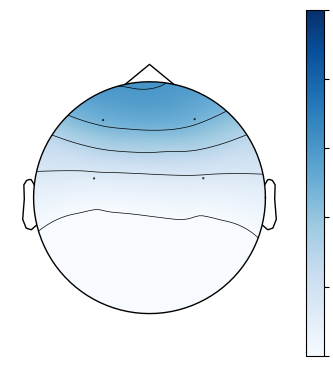

Stage N2:
Preferred Phase:       3.139 rad
Modulation Index:      0.612
Mean Vector Length:    0.719
Rayleigh z:            1521.644
p-value:               0.000
Coupling Density:      1.139
Stage SWS:
Preferred Phase:       -3.141 rad
Modulation Index:      0.724
Mean Vector Length:    0.951
Rayleigh z:            768.839
p-value:               0.000
Coupling Density:      1.224


Exception ignored in: 'read_from_file_callback'
Traceback (most recent call last):
  File "y:\SNL\HSR\somnopy-v2-main\.venv\Lib\site-packages\matplotlib\backends\backend_agg.py", line 219, in get_text_width_height_descent
    font.set_text(s, 0.0, flags=get_hinting_flag())
OSError: [Errno 22] Invalid argument
Exception ignored in: 'read_from_file_callback'
Traceback (most recent call last):
  File "y:\SNL\HSR\somnopy-v2-main\.venv\Lib\site-packages\matplotlib\backends\backend_agg.py", line 219, in get_text_width_height_descent
    font.set_text(s, 0.0, flags=get_hinting_flag())
OSError: [Errno 22] Invalid argument
Exception ignored in: 'read_from_file_callback'
Traceback (most recent call last):
  File "y:\SNL\HSR\somnopy-v2-main\.venv\Lib\site-packages\matplotlib\backends\backend_agg.py", line 219, in get_text_width_height_descent
    font.set_text(s, 0.0, flags=get_hinting_flag())
OSError: [Errno 22] Invalid argument
Exception ignored in: 'read_from_file_callback'
Traceback (most rec

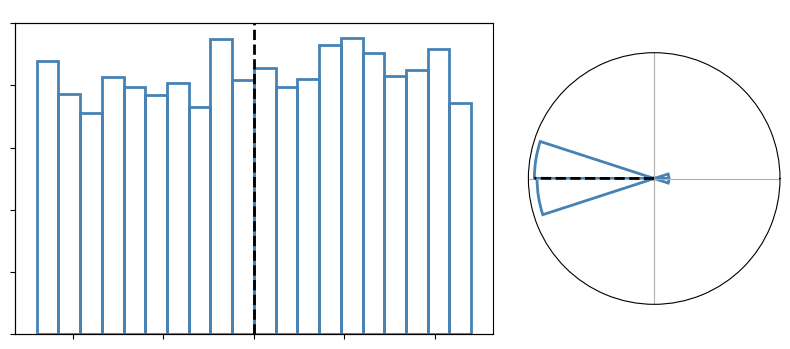

📄 Saved: Somnopy_HSR127_W2_V1_Overnight_2025-07-28.csv
✅ Finished HSR127_W2_V1_Overnight in 15m 12s

🧠 Processing: HSR128_W1_V1_Overnight
Start event detection for subject HSR128_W1_V1_Overnight.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Detected SOs in stage N2
Method: Staresina
PTP amplitude: 150.7683
Mean Duration: 1.2329
SO Density per 30s: 3.7200
Total Count: 5208
---------------------------------------------------------------
Detected SOs in stage SWS
Method: Staresina
PTP amplitude: 181.4709
Mean Duration: 1.1868
SO Density per 30s: 3.9394
Total Count: 3183
---------------------------------------------------------------
Detected SPs in stage N2
Method: Hahn2020
Average Amplitude: 13.5541 uv
Average Duration: 1.0308s
Spindle Density (per 30s): 3.7200
Total Spindle Count: 5208
---------------------------------------------------------------
Detected SPs in stage SWS
Method: Hahn2020
Average Amplitude: 10.7381 uv
Average Duration: 0.9379s
Spindl

Exception ignored in: 'read_from_file_callback'
Traceback (most recent call last):
  File "y:\SNL\HSR\somnopy-v2-main\.venv\Lib\site-packages\matplotlib\backends\backend_agg.py", line 219, in get_text_width_height_descent
    font.set_text(s, 0.0, flags=get_hinting_flag())
OSError: [Errno 22] Invalid argument
Exception ignored in: 'read_from_file_callback'
Traceback (most recent call last):
  File "y:\SNL\HSR\somnopy-v2-main\.venv\Lib\site-packages\matplotlib\backends\backend_agg.py", line 219, in get_text_width_height_descent
    font.set_text(s, 0.0, flags=get_hinting_flag())
OSError: [Errno 22] Invalid argument
Exception ignored in: 'read_from_file_callback'
Traceback (most recent call last):
  File "y:\SNL\HSR\somnopy-v2-main\.venv\Lib\site-packages\matplotlib\backends\backend_agg.py", line 219, in get_text_width_height_descent
    font.set_text(s, 0.0, flags=get_hinting_flag())
OSError: [Errno 22] Invalid argument
Exception ignored in: 'read_from_file_callback'
Traceback (most rec

Spindles coupled with SOs in stage N2: 53.40%
SOs coupled with spindles in stage N2: 53.40%
Spindles coupled with SOs in stage SWS: 52.32%
SOs coupled with spindles in stage SWS: 52.12%
event_summary
    stage channel  stage_dur  mean_SO_amp  mean_SO_dur  SO_density  \
0      2      C3      10500     0.000135     1.198003    1.837143   
1      2      C4      10500     0.000149     1.253693    1.654286   
2      2      F3      10500     0.000155     1.227611    6.545714   
3      2      F4      10500     0.000153     1.246135    4.842857   
4      2     all      10500     0.000151     1.232884    3.720000   
5      3      C3       6060     0.000156     1.102922    1.084158   
6      3      C4       6060     0.000152     1.198048    1.039604   
7      3      F3       6060     0.000184     1.166369    7.559406   
8      3      F4       6060     0.000188     1.225244    6.074257   
9      3     all       6060     0.000181     1.186789    3.939356   
10   all      C3      16560     0.000140

Exception ignored in: 'read_from_file_callback'
Traceback (most recent call last):
  File "y:\SNL\HSR\somnopy-v2-main\.venv\Lib\site-packages\matplotlib\backends\backend_agg.py", line 219, in get_text_width_height_descent
    font.set_text(s, 0.0, flags=get_hinting_flag())
OSError: [Errno 22] Invalid argument
Exception ignored in: 'read_from_file_callback'
Traceback (most recent call last):
  File "y:\SNL\HSR\somnopy-v2-main\.venv\Lib\site-packages\matplotlib\backends\backend_agg.py", line 219, in get_text_width_height_descent
    font.set_text(s, 0.0, flags=get_hinting_flag())
OSError: [Errno 22] Invalid argument
Exception ignored in: 'read_from_file_callback'
Traceback (most recent call last):
  File "y:\SNL\HSR\somnopy-v2-main\.venv\Lib\site-packages\matplotlib\backends\backend_agg.py", line 219, in get_text_width_height_descent
    font.set_text(s, 0.0, flags=get_hinting_flag())
OSError: [Errno 22] Invalid argument
Exception ignored in: 'read_from_file_callback'
Traceback (most rec

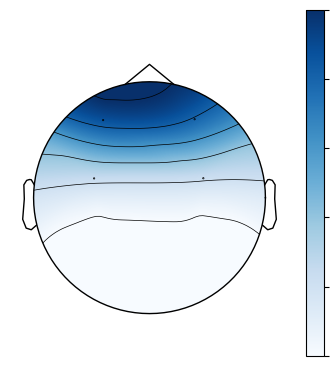

Stage N2:
Preferred Phase:       -2.702 rad
Modulation Index:      0.002
Mean Vector Length:    0.009
Rayleigh z:            0.181
p-value:               0.985
Coupling Density:      1.986


In [ ]:
# ----------------- STEP 2 & 3: Run Processing + Save CSV ------------------- #
print("\n⚙️ STEP 2: Running analysis and saving output...\n")

for folder_name in os.listdir(root_dir):
    folder_path = os.path.join(root_dir, folder_name)

    if os.path.isdir(folder_path) and folder_name.startswith("HSR"):
        print(f"\n🧠 Processing: {folder_name}")
        processed_eeg_folder = folder_path
        scoring_file = folder_path

        try:
            start_time = time.time()

            event_summary_all, coupling_event_all, so_waveform_all = get_sosp_for_folder(
                processed_eeg_folder,
                scoring_file,
                chan_limit=chan_limit,
                coupling=coupling,
                interest_stage=interest_stage,
                sp_method=sp_method,
                so_method=so_method,
                scoring_dur=scoring_dur
            )

            # ----------------- STEP 3: Save Output CSV ------------------- #
            if isinstance(event_summary_all, dict):
                for key, df in event_summary_all.items():
                    if isinstance(df, pd.DataFrame):
                        key_safe = key.replace(" ", "_").replace("/", "_")
                        csv_name = f"Somnopy_{folder_name}_{today_str}.csv"
                        csv_path = os.path.join(folder_path, csv_name)
                        df.to_csv(csv_path, index=False)
                        print(f"📄 Saved: {csv_name}")
            else:
                print(f"⚠️ Unexpected format for event_summary_all in {folder_name}")

            end_time = time.time()
            duration = end_time - start_time
            print(f"✅ Finished {folder_name} in {int(duration//60)}m {int(duration%60)}s")

        except Exception as e:
            print(f"❌ Error processing {folder_name}: {e}")


In [ ]:
# ----------------- STEP 2 & 3: Run Processing + Save CSV (WITH SWA DETECTION) ------------------- #
print("\n⚙️ STEP 2: Running analysis with SWA detection and saving output...\n")

for folder_name in os.listdir(root_dir):
    folder_path = os.path.join(root_dir, folder_name)

    if os.path.isdir(folder_path) and folder_name.startswith("HSR"):
        print(f"\n🧠 Processing: {folder_name}")
        processed_eeg_folder = folder_path
        scoring_file = folder_path

        try:
            start_time = time.time()

            # Standard SOSP analysis
            event_summary_all, coupling_event_all, so_waveform_all = get_sosp_for_folder(
                processed_eeg_folder,
                scoring_file,
                chan_limit=chan_limit,
                coupling=coupling,
                interest_stage=interest_stage,
                sp_method=sp_method,
                so_method=so_method,
                scoring_dur=scoring_dur
            )

            # ----------------- STEP 3A: Save Standard Output CSV ------------------- #
            if isinstance(event_summary_all, dict):
                for key, df in event_summary_all.items():
                    if isinstance(df, pd.DataFrame):
                        key_safe = key.replace(" ", "_").replace("/", "_")
                        csv_name = f"Somnopy_{folder_name}_{today_str}.csv"
                        csv_path = os.path.join(folder_path, csv_name)
                        df.to_csv(csv_path, index=False)
                        print(f"📄 Saved: {csv_name}")
            else:
                print(f"⚠️ Unexpected format for event_summary_all in {folder_name}")

            # ----------------- STEP 3B: SWA Detection ------------------- #
            print(f"🌊 Running SWA detection for {folder_name}...")
            
            try:
                # Load PSG data for SWA detection
                psg = PolySomnoGraphy(processed_eeg_folder, scoring_file)
                psg.set_up_raw(
                    channels_to_drop=channels_to_drop,
                    chan_limit=chan_limit,
                    rereference=rereference,
                    montage_temp=montage_temp
                )
                
                # Dictionary to store SWA results for all channels
                swa_results_all = {}
                
                # Run SWA detection for each stage of interest
                for stage in interest_stage:
                    print(f"   Detecting SWA in stage {stage}...")
                    
                    # Get channel names
                    channels = psg.raw.ch_names if chan_limit is None else chan_limit
                    eeg_channels = [ch for ch in channels if ch not in channels_to_drop]
                    
                    for channel in eeg_channels:
                        try:
                            # Run SWA detection for this channel and stage
                            swa_events = detect_swa(
                                psg.raw,
                                psg.hypnogram, 
                                stage=stage,
                                channel=channel,
                                baseline=baseline
                            )
                            
                            # Store results
                            key = f"{stage}_{channel}"
                            swa_results_all[key] = swa_events
                            
                            if swa_events is not None and len(swa_events) > 0:
                                print(f"     {channel}: Found {len(swa_events)} SWA events")
                            else:
                                print(f"     {channel}: No SWA events found")
                                
                        except Exception as e:
                            print(f"     ⚠️ {channel}: Error in SWA detection - {e}")
                            swa_results_all[f"{stage}_{channel}"] = None
                
                # ----------------- STEP 3C: Save SWA Results ------------------- #
                swa_csv_name = f"SWA_{folder_name}_{today_str}.csv"
                swa_csv_path = os.path.join(folder_path, swa_csv_name)
                
                # Convert SWA results to DataFrame format
                swa_summary_data = []
                for key, events in swa_results_all.items():
                    stage_name, channel = key.rsplit('_', 1)
                    
                    if events is not None and len(events) > 0:
                        # Calculate summary statistics
                        if hasattr(events, 'duration'):
                            durations = events.duration if hasattr(events.duration, '__iter__') else [events.duration]
                            mean_duration = np.mean(durations)
                            total_count = len(durations)
                        else:
                            # If events is a DataFrame or similar structure
                            mean_duration = np.nan
                            total_count = len(events) if hasattr(events, '__len__') else 1
                            
                        swa_summary_data.append({
                            'stage': stage_name,
                            'channel': channel,
                            'swa_count': total_count,
                            'mean_duration': mean_duration,
                            'swa_density': total_count / (psg.get_stage_duration(stage_name) / 30) if hasattr(psg, 'get_stage_duration') else np.nan
                        })
                    else:
                        swa_summary_data.append({
                            'stage': stage_name,
                            'channel': channel,
                            'swa_count': 0,
                            'mean_duration': np.nan,
                            'swa_density': 0
                        })
                
                # Save SWA summary to CSV
                if swa_summary_data:
                    swa_df = pd.DataFrame(swa_summary_data)
                    swa_df.to_csv(swa_csv_path, index=False)
                    print(f"🌊 Saved SWA results: {swa_csv_name}")
                else:
                    print(f"⚠️ No SWA data to save for {folder_name}")
                    
            except Exception as swa_error:
                print(f"❌ Error in SWA detection for {folder_name}: {swa_error}")
                
            end_time = time.time()
            duration = end_time - start_time
            print(f"✅ Finished {folder_name} in {int(duration//60)}m {int(duration%60)}s")

        except Exception as e:
            print(f"❌ Error processing {folder_name}: {e}")


In [ ]:
# ----------------- ALTERNATIVE: Simple SWA Detection Integration ------------------- #
# Run this cell if the above cell encounters issues with detect_swa parameters

print("\n🌊 ALTERNATIVE: Simple SWA Detection for all processed folders...\n")

for folder_name in os.listdir(root_dir):
    folder_path = os.path.join(root_dir, folder_name)

    if os.path.isdir(folder_path) and folder_name.startswith("HSR"):
        print(f"\n🌊 Running SWA detection for: {folder_name}")
        
        try:
            # Load PSG data
            psg = PolySomnoGraphy(folder_path, folder_path)
            psg.set_up_raw(
                channels_to_drop=channels_to_drop,
                chan_limit=chan_limit,
                rereference=rereference,
                montage_temp=montage_temp
            )
            
            # Initialize SWA results storage
            swa_results = []
            
            # Get EEG channels
            eeg_channels = chan_limit if chan_limit is not None else psg.raw.ch_names
            eeg_channels = [ch for ch in eeg_channels if ch not in channels_to_drop]
            
            for stage in interest_stage:
                print(f"   Stage {stage}:")
                for channel in eeg_channels:
                    try:
                        # Try basic detect_swa call - adjust parameters as needed
                        swa_events = detect_swa(psg.raw, psg.hypnogram, stage, channel)
                        
                        if swa_events is not None:
                            # Extract relevant metrics
                            if hasattr(swa_events, '__len__'):
                                swa_count = len(swa_events)
                            else:
                                swa_count = 1 if swa_events else 0
                                
                            swa_results.append({
                                'folder': folder_name,
                                'stage': stage,
                                'channel': channel,
                                'swa_count': swa_count,
                                'swa_events': str(swa_events)  # Store as string for CSV
                            })
                            
                            print(f"     {channel}: {swa_count} SWA events")
                        else:
                            swa_results.append({
                                'folder': folder_name,
                                'stage': stage,
                                'channel': channel,
                                'swa_count': 0,
                                'swa_events': 'None'
                            })
                            print(f"     {channel}: No SWA events")
                            
                    except Exception as e:
                        print(f"     ⚠️ {channel}: Error - {str(e)[:50]}...")
                        swa_results.append({
                            'folder': folder_name,
                            'stage': stage,
                            'channel': channel,
                            'swa_count': 0,
                            'swa_events': f'Error: {str(e)[:50]}'
                        })
            
            # Save results for this folder
            if swa_results:
                folder_swa_df = pd.DataFrame([r for r in swa_results if r['folder'] == folder_name])
                swa_csv_path = os.path.join(folder_path, f"SWA_Simple_{folder_name}_{today_str}.csv")
                folder_swa_df.to_csv(swa_csv_path, index=False)
                print(f"🌊 Saved: SWA_Simple_{folder_name}_{today_str}.csv")
                
        except Exception as e:
            print(f"❌ Error processing {folder_name}: {e}")
